In [26]:
import keras
from keras.utils import plot_model, custom_object_scope
from keras_self_attention import SeqSelfAttention
from pathlib import Path
import os
import sys
sys.path.insert(0, '../../')
from config import get_path, setup_workdir

# Base paths
MODELS_DIR = get_path("models")
FIGURES_DIR = get_path("figures")

# Available models
MODELS = {
    "ceo2_clusters": MODELS_DIR / "ceo2_clusters" / "tuned_sliced_ceo2_calc_2-12_retrain.h5",
    "ce_clusters": MODELS_DIR / "ce_clusters" / "tuned_sliced_ce_calc_2-12_retrain.h5",
    "csd": MODELS_DIR / "csd" / "tuned_csd_2-12.h5",
}

# Output directory for figures
OUTPUT_DIR = FIGURES_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [27]:
# Load the CeO2 clusters model
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    ceo2_model = keras.models.load_model(str(MODELS["ceo2_clusters"]))
print(f"Loaded: {MODELS['ceo2_clusters']}")

2026-02-13 14:44:12.553548: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: /usr/lib/x86_64-linux-gnu/libcuda.so.1: file too short
2026-02-13 14:44:12.553607: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2026-02-13 14:44:12.553645: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:163] no NVIDIA GPU device is present: /dev/nvidia0 does not exist
2026-02-13 14:44:12.554219: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loaded: /workspace/home/pdf-nn-data/models/ceo2_clusters/tuned_sliced_ceo2_calc_2-12_retrain.h5


Graphviz dot: /usr/bin/dot
pydot version: 2.0.0


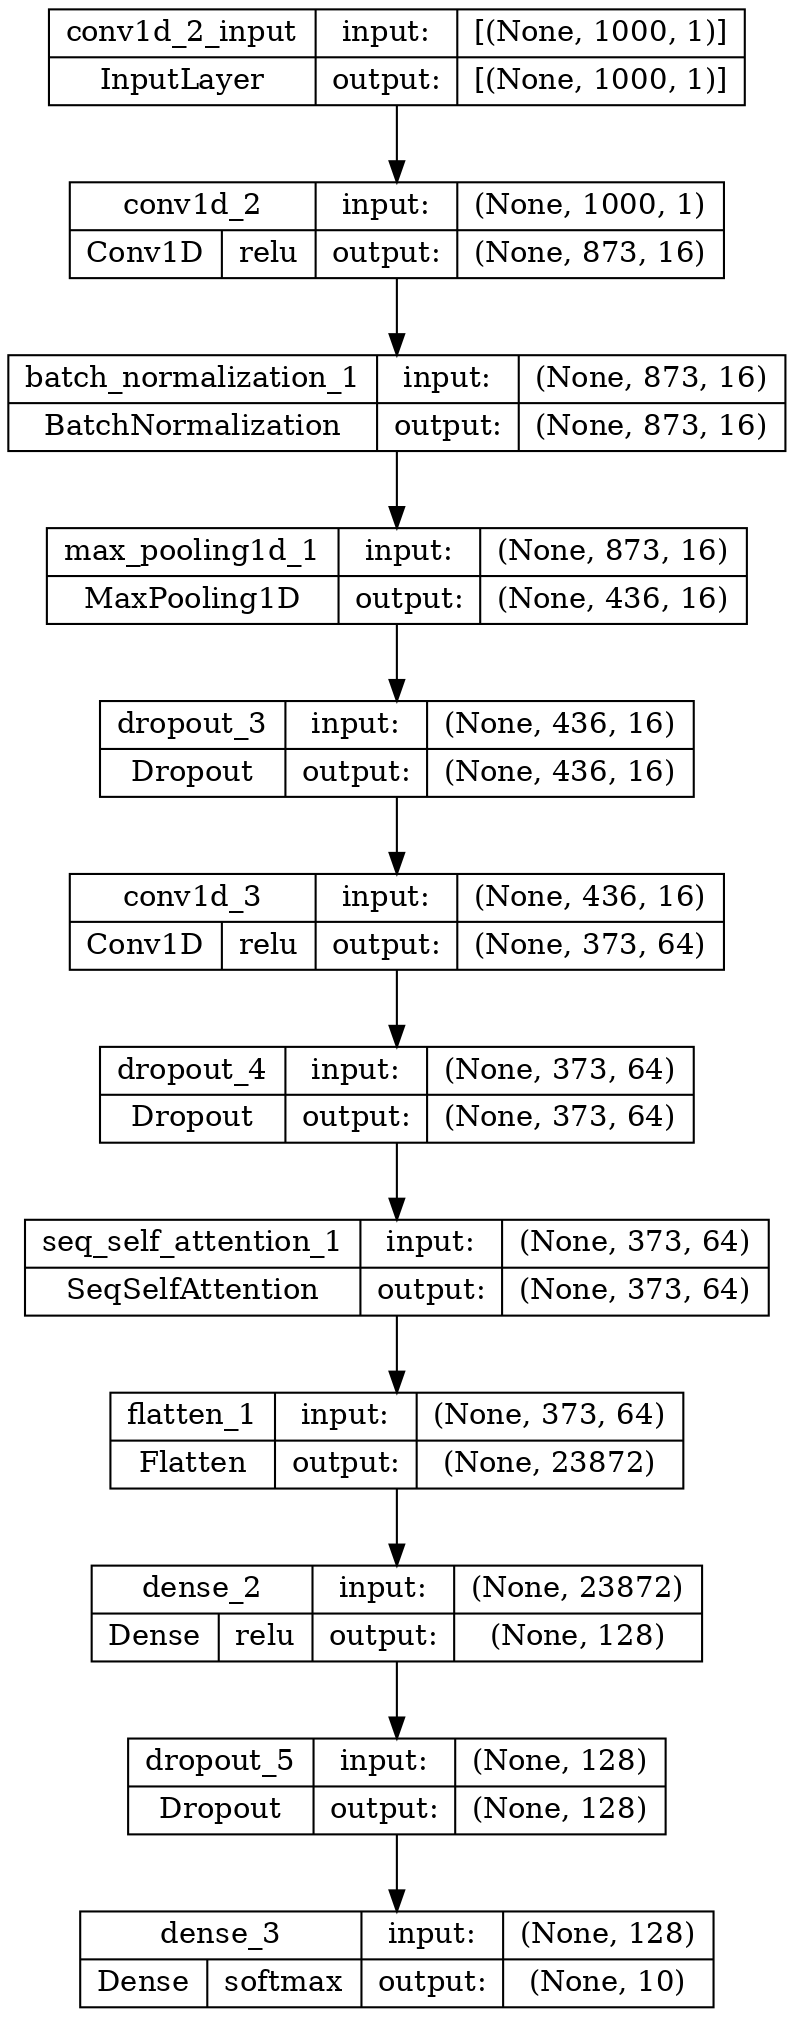

In [36]:
# Plot model architecture using Keras plot_model (vertical layout)
import importlib
import shutil
import pydot
import keras.utils.vis_utils as vis_utils

dot_path = shutil.which("dot")
if dot_path is None:
    raise RuntimeError("Graphviz 'dot' not found in PATH. Install graphviz and restart the kernel.")
print(f"Graphviz dot: {dot_path}")
print(f"pydot version: {pydot.__version__}")

# Reload vis_utils in case Keras was imported before pydot install
importlib.reload(vis_utils)
plot_model = vis_utils.plot_model

plot_model(
    ceo2_model,
    to_file=os.path.join(OUTPUT_DIR, "ceo2_model_architecture.png"),
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir="TB",  # Top to Bottom
    expand_nested=True,
    dpi=150,
    show_layer_activations=True
)

In [37]:
# Model summary
ceo2_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 873, 16)           2064      
                                                                 
 batch_normalization_1 (Batc  (None, 873, 16)          64        
 hNormalization)                                                 
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 436, 16)          0         
 1D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 436, 16)           0         
                                                                 
 conv1d_3 (Conv1D)           (None, 373, 64)           65600     
                                                                 
 dropout_4 (Dropout)         (None, 373, 64)          

In [41]:
# Load Ce clusters model
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    ce_model = keras.models.load_model(MODELS["ce_clusters"])
print(f"Loaded: {MODELS['ce_clusters']}")

Loaded: /workspace/home/pdf-nn-data/models/ce_clusters/tuned_sliced_ce_calc_2-12_retrain.h5


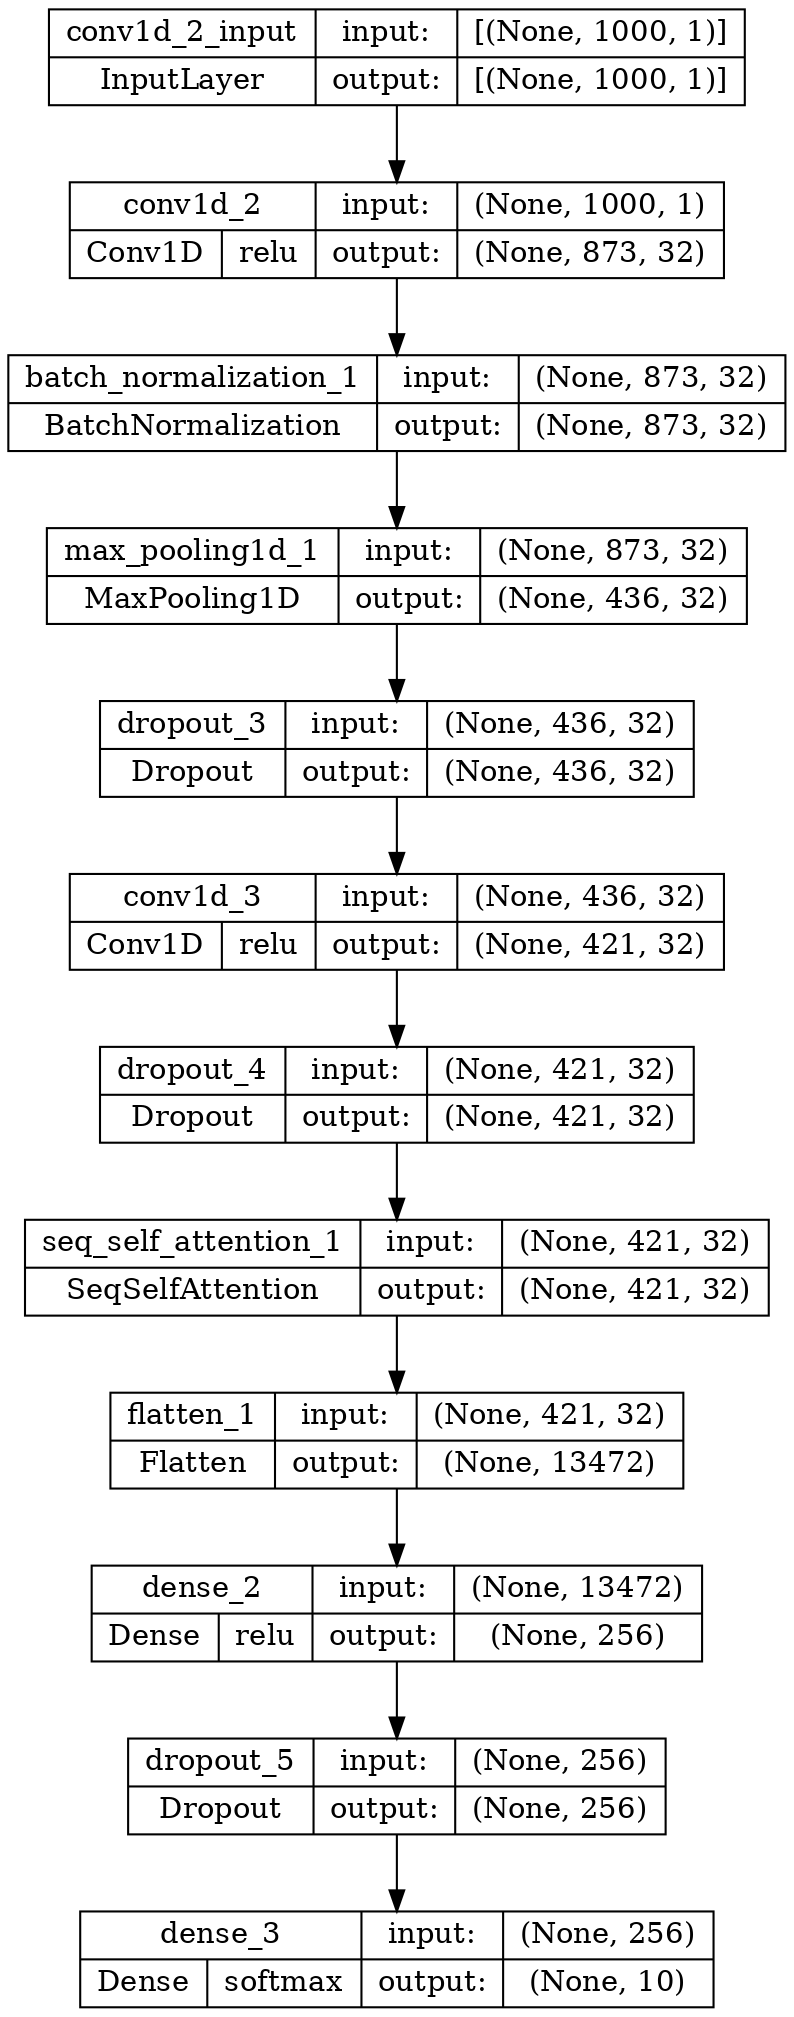

In [ ]:
plot_model(
    ce_model,
    to_file=os.path.join(OUTPUT_DIR, "ce_model_horizontal.png"),
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=150,
    show_layer_activations=True
)

In [38]:
# Load the CSD model
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    csd_model = keras.models.load_model(MODELS["csd"])
print(f"Loaded: {MODELS['csd']}")

Loaded: /workspace/home/pdf-nn-data/models/csd/tuned_csd_2-12.h5


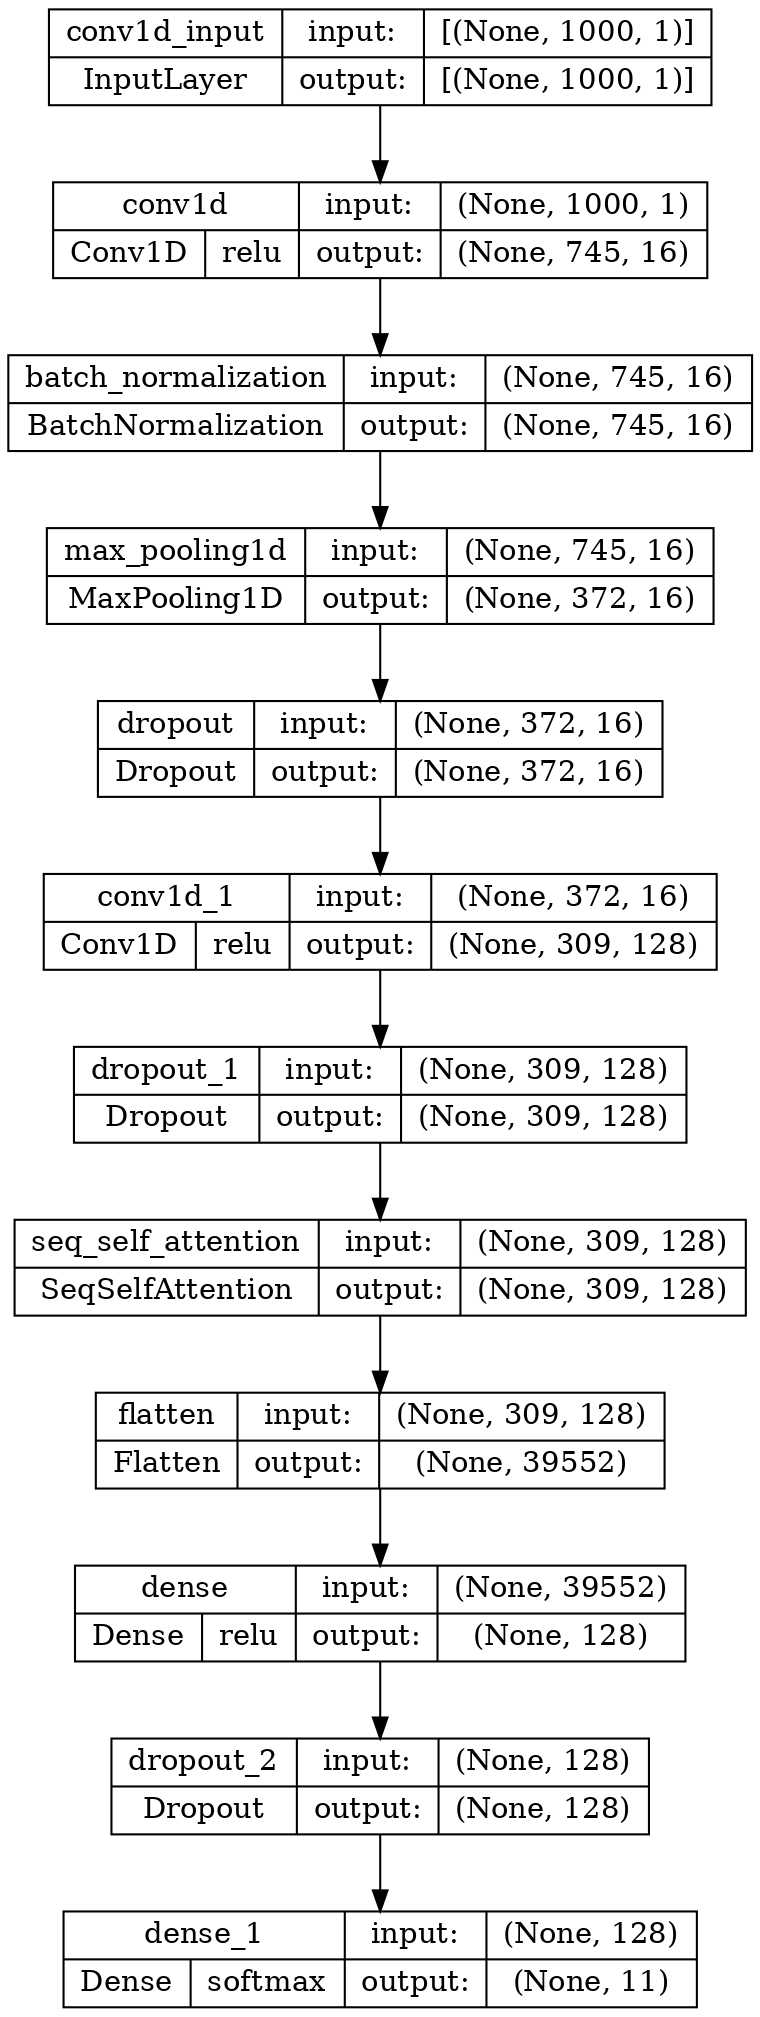

In [ ]:
plot_model(
    csd_model,
    to_file=os.path.join(OUTPUT_DIR, "csd_model_architecture.png"),
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=150,
    show_layer_activations=True
)

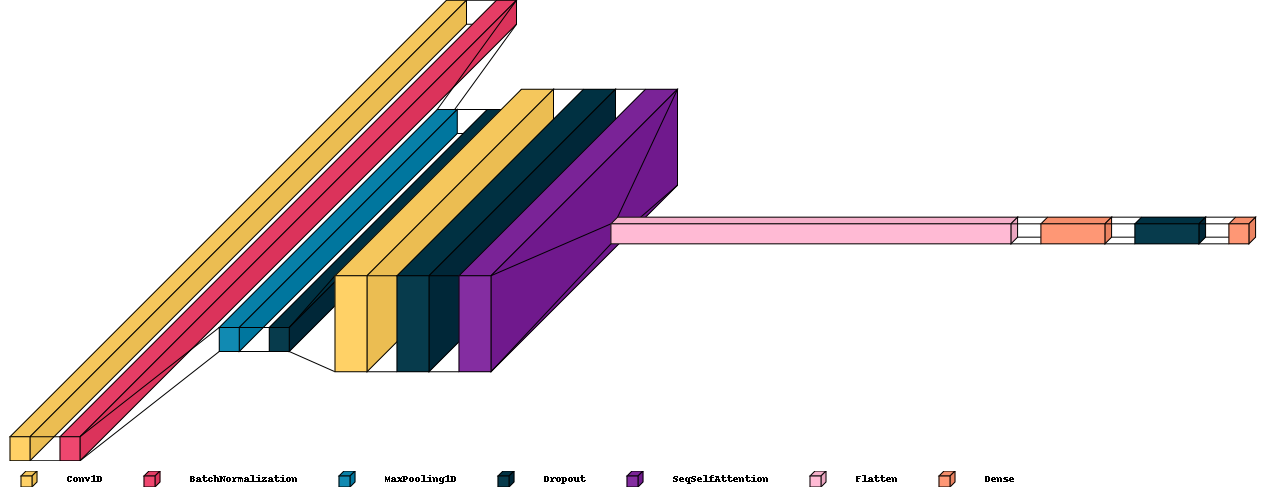

In [54]:
# Visualize with visualkeras for a more aesthetic representation
import visualkeras
from PIL import ImageFont

# Try to use a nicer font (falls back to default if not available)
try:
    font = ImageFont.truetype("Arial", 16)
except:
    font = None

visualkeras.layered_view(
    ceo2_model, 
    to_file=os.path.join(OUTPUT_DIR, 'ceo2_model_visualkeras.png'),
    legend=True,
    font=font,
    scale_xy=1.5,
    scale_z=0.5,
    spacing=30
)

## Compare All Models Side by Side

Generate visualizations for all three trained models (CeO2 clusters, Ce40 clusters, CSD) for comparison.

In [49]:
# Generate visualizations for all models
import matplotlib.pyplot as plt
from matplotlib.image import imread

models_dict = {
    "CeO2 Clusters": ceo2_model,
    "Ce Clusters": ce_model, 
    "CSD": csd_model
}

# Generate layered views for all models
for name, model in models_dict.items():
    filename = f"{name.lower().replace(' ', '_')}_layered.png"
    visualkeras.layered_view(
        model,
        to_file=os.path.join(OUTPUT_DIR, filename),
        legend=True,
        color_map=color_map,
        scale_xy=1.5,
        scale_z=0.5,
        spacing=30,
        draw_volume=True
    )
    print(f"Generated: {filename}")

Generated: ceo2_clusters_layered.png
Generated: ce_clusters_layered.png
Generated: csd_layered.png


/workspace/miniconda3/envs/pdfnn/lib/python3.7/site-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


In [50]:
# Display model summaries comparison
print("=" * 80)
for name, model in models_dict.items():
    print(f"\n{name} Model")
    print("-" * 40)
    print(f"Total parameters: {model.count_params():,}")
    print(f"Trainable parameters: {sum([layer.count_params() for layer in model.layers if layer.trainable]):,}")
    print(f"Number of layers: {len(model.layers)}")
print("=" * 80)


CeO2 Clusters Model
----------------------------------------
Total parameters: 3,128,859
Trainable parameters: 3,128,859
Number of layers: 11

Ce Clusters Model
----------------------------------------
Total parameters: 3,473,355
Trainable parameters: 3,473,355
Number of layers: 11

CSD Model
----------------------------------------
Total parameters: 5,215,964
Trainable parameters: 5,215,964
Number of layers: 11
